1. importar librerias

In [14]:
pip install bokeh

Note: you may need to restart the kernel to use updated packages.Collecting bokeh
   ---------------------------------------- 0.0/6.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.4 MB ? eta -:--:--
   ------------------- -------------------- 3.1/6.4 MB 13.2 MB/s eta 0:00:01
   ---------------------------------- ----- 5.5/6.4 MB 11.6 MB/s eta 0:00:01
   ---------------------------------------- 6.4/6.4 MB 11.6 MB/s  0:00:00

   -------------------- ------------------- 1/2 [bokeh]
   -------------------- ------------------- 1/2 [bokeh]
   -------------------- ------------------- 1/2 [bokeh]
   -------------------- ------------------- 1/2 [bokeh]
   -------------------- ------------------- 1/2 [bokeh]
   -------------------- ------------------- 1/2 [bokeh]
   -------------------- ------------------- 1/2 [bokeh]
   -------------------- ------------------- 1/2 [bokeh]
   -------------------- ------------------- 1/2 [bokeh]
   -------------------- ------------------- 1/2


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource

2. Leer CSV

In [16]:
df_estudiantes = pd.read_csv("data/estudiantes.csv")

df_estudiantes.head()

,id_estudiante,nombre,carrera,edad,genero,semestre
0,1,Luis Pérez,Educación,26,Masculino,4
1,2,Carlos Gómez,Educación,35,Masculino,10
2,3,Pedro Pérez,Sistemas,20,Masculino,4
3,4,Andrés Ruiz,Sistemas,35,Masculino,9
4,5,Pedro López,Derecho,26,Masculino,3


3. CONECTARME A SQL

In [17]:
conn = sqlite3.connect("data/universidad.db")
query = "SELECT * FROM notas"

df_notas = pd.read_sql(query, conn)
df_notas.head()

,id_nota,id_estudiante,materia,nota,asistencia
0,1,913,Python,8.71,75
1,2,1829,Base de Datos,8.68,94
2,3,713,Auditoría,7.11,61
3,4,768,Matemáticas,6.16,98
4,5,218,Programación,5.99,94


In [ ]:
4. EJECUTAR A SQL

In [18]:
query = """
SELECT materia, AVG(nota) AS promedio_nota
FROM notas
GROUP BY materia
"""

df_promedio = pd.read_sql(query, conn)

df_promedio

,materia,promedio_nota
0,Administración,7.549163
1,Auditoría,7.491745
2,Base de Datos,7.446033
3,Contabilidad,7.522060
4,Estadística,7.422652
5,Inglés,7.589539
6,Investigación,7.445900
7,Matemáticas,7.470337
8,Programación,7.442886
9,Python,7.340020


In [19]:
5. UNIR DATASETS unir CSV + Base de datos

SyntaxError: invalid syntax (3393798440.py, line 1)

In [20]:
df_final = pd.merge(
    df_estudiantes,
    df_notas,
    on="id_estudiante"
)

df_final.head()

,id_estudiante,nombre,carrera,edad,genero,semestre,id_nota,materia,nota,asistencia
0,2,Carlos Gómez,Educación,35,Masculino,10,1347,Python,9.91,98
1,2,Carlos Gómez,Educación,35,Masculino,10,1534,Base de Datos,8.30,88
2,3,Pedro Pérez,Sistemas,20,Masculino,4,3482,Estadística,6.26,95
3,3,Pedro Pérez,Sistemas,20,Masculino,4,3827,Python,8.10,60
4,3,Pedro Pérez,Sistemas,20,Masculino,4,4743,Programación,9.84,74


6. revisar dataset final

In [6]:
df_final.shape

(5000, 10)

In [21]:
df_final.to_csv("data/dataset_final.csv", index=False, encoding="utf-8")

print("Dataset final guardado correctamente.")

Dataset final guardado correctamente.


7. Visualizaciones
Gráfico 1: promedio por carrera

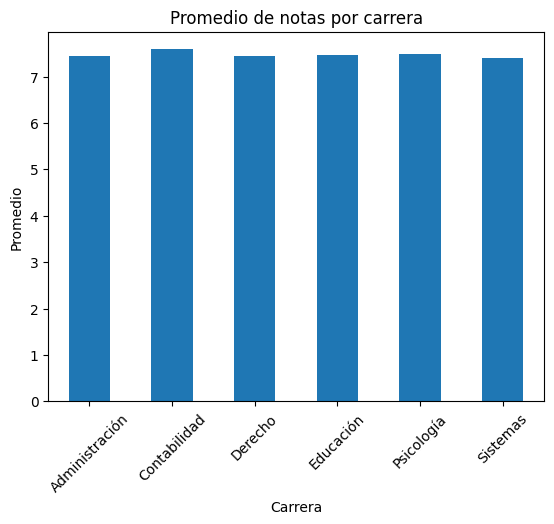

In [22]:
promedio_carrera = df_final.groupby("carrera")["nota"].mean()

promedio_carrera.plot(kind="bar")

plt.title("Promedio de notas por carrera")
plt.xlabel("Carrera")
plt.ylabel("Promedio")
plt.xticks(rotation=45)
plt.show()

Gráfico 2: cantidad de estudiantes por carrera

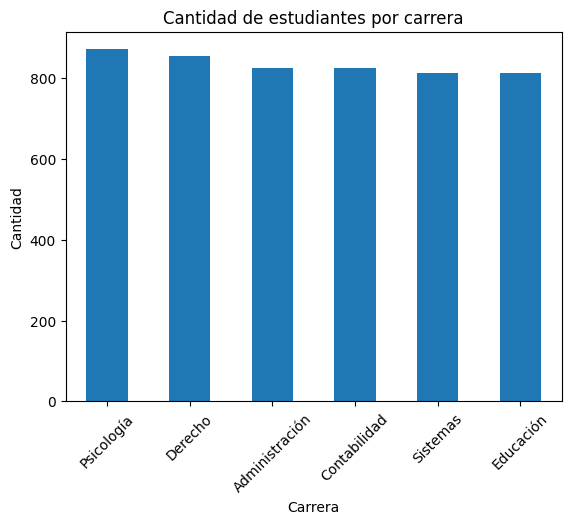

In [23]:
conteo_carrera = df_estudiantes["carrera"].value_counts()

conteo_carrera.plot(kind="bar")

plt.title("Cantidad de estudiantes por carrera")
plt.xlabel("Carrera")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

In [27]:
cantidad_carrera = df_estudiantes["carrera"].value_counts().reset_index()
cantidad_carrera.columns = ["carrera", "cantidad"]

source = ColumnDataSource(cantidad_carrera)

p = figure(
    x_range=cantidad_carrera["carrera"],
    height=400,
    width=800,
    title="Cantidad de estudiantes por carrera",
    toolbar_location="above"
)

p.vbar(
    x="carrera",
    top="cantidad",
    width=0.6,
    source=source
)

p.xaxis.axis_label = "Carrera"
p.yaxis.axis_label = "Cantidad de estudiantes"
p.xaxis.major_label_orientation = 0.8

show(p)

Gráfico 3: promedio por materia

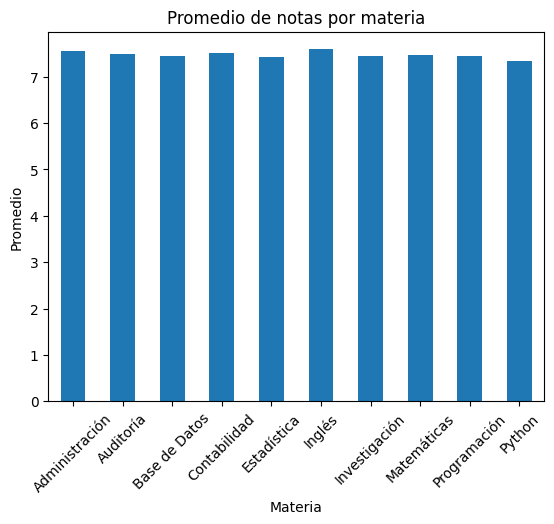

In [10]:
promedio_materia = df_final.groupby("materia")["nota"].mean()

promedio_materia.plot(kind="bar")

plt.title("Promedio de notas por materia")
plt.xlabel("Materia")
plt.ylabel("Promedio")
plt.xticks(rotation=45)
plt.show()

Gráfico 4: Distribución de notas por cantidad de estudiantes

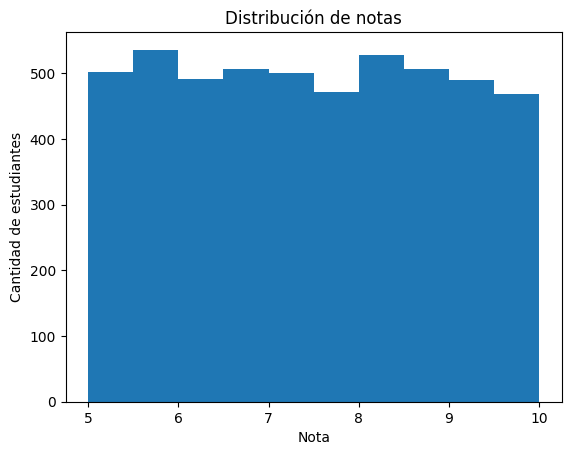

In [11]:
plt.hist(df_final["nota"], bins=10)

plt.title("Distribución de notas")
plt.xlabel("Nota")
plt.ylabel("Cantidad de estudiantes")

plt.show()

Cantidad por género

In [28]:
genero = df_final["genero"].value_counts().reset_index()
genero.columns = ["genero", "cantidad"]

source = ColumnDataSource(genero)

p = figure(
    x_range=genero["genero"],
    title="Cantidad de estudiantes por género",
    width=700,
    height=400
)

p.vbar(
    x="genero",
    top="cantidad",
    width=0.5,
    source=source
)

p.xaxis.axis_label = "Género"
p.yaxis.axis_label = "Cantidad"

show(p)